# Sentiment Analysis using SVM with TF-IDF

## CSE 4221 — Natural Language Processing Assignment

**Model:** Support Vector Machine (Linear Kernel)  
**Features:** TF-IDF (300 features)  
**Dataset:** IMDB Movie Review Dataset  
**Task:** Binary Sentiment Classification (Positive / Negative)

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load the IMDB Dataset

In [2]:
# Download dataset from Google Drive
import gdown

url = 'https://drive.google.com/uc?id=1GOOxQZSmtQZ4q-UPVh87DHOgI79cx9vI'
output = 'IMDB-Dataset.csv'
gdown.download(url, output, quiet=False)

# Load dataset
df = pd.read_csv('IMDB-Dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1GOOxQZSmtQZ4q-UPVh87DHOgI79cx9vI
To: /content/IMDB-Dataset.csv
100%|██████████| 66.2M/66.2M [00:00<00:00, 108MB/s] 


Dataset shape: (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Class distribution
print('Sentiment Distribution:')
print(df['sentiment'].value_counts())

# Check for missing values and duplicates
print(f'\nMissing values: {df.isnull().sum().sum()}')
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'After removing duplicates: {df.shape}')

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 418
After removing duplicates: (49582, 2)


---
## 3. Text Preprocessing

Steps: Remove HTML → Remove special chars → Lowercase → Remove stopwords → Lemmatize

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean and preprocess a single review."""
    text = re.sub(r'<[^>]+>', '', text)          # Remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)       # Keep only letters
    text = text.lower()                           # Lowercase
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print('Preprocessing reviews...')
df['cleaned_review'] = df['review'].apply(preprocess_text)
print('Preprocessing complete.')

# Show sample
print('\n--- Original ---')
print(df['review'].iloc[0][:200])
print('\n--- Cleaned ---')
print(df['cleaned_review'].iloc[0][:200])

Preprocessing reviews...
Preprocessing complete.

--- Original ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

--- Cleaned ---
one reviewer mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scene violence set right word trust show faint hearted timid show pull punch regard drug 


In [5]:
# Encode labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(df[['sentiment', 'label']].drop_duplicates())

  sentiment  label
0  positive      1
3  negative      0


---
## 4. Train-Test Split (80:20)

In [6]:
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {len(X_train)}')
print(f'Test set:     {len(X_test)}')

Training set: 39665
Test set:     9917


---
## 5. Feature Extraction — TF-IDF (300 Features)

TF-IDF weights terms by their frequency in a document relative to their frequency across the corpus, down-weighting common terms and up-weighting discriminative ones.

In [7]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),   # Unigrams + bigrams
    sublinear_tf=True     # Log-scaled term frequency
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f'TF-IDF Training matrix: {X_train_tfidf.shape}')
print(f'TF-IDF Test matrix:     {X_test_tfidf.shape}')
print(f'\nSample features: {tfidf_vectorizer.get_feature_names_out()[:15].tolist()}')

TF-IDF Training matrix: (39665, 300)
TF-IDF Test matrix:     (9917, 300)

Sample features: ['act', 'acting', 'action', 'actor', 'actually', 'almost', 'along', 'also', 'although', 'always', 'american', 'another', 'anyone', 'anything', 'around']


---
## 6. Model Training — Linear SVM

Linear SVM finds the maximum-margin hyperplane separating positive and negative reviews in the TF-IDF feature space.

In [8]:
svm_model = LinearSVC(max_iter=2000, random_state=42, C=1.0)
svm_model.fit(X_train_tfidf, y_train)
print('Linear SVM model trained successfully.')

Linear SVM model trained successfully.


---
## 7. Prediction and Evaluation

In [9]:
y_pred = svm_model.predict(X_test_tfidf)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 50)
print('  SVM + TF-IDF — RESULTS')
print('=' * 50)
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')
print('=' * 50)

  SVM + TF-IDF — RESULTS
  Accuracy:  0.8155
  Precision: 0.8062
  Recall:    0.8324
  F1-Score:  0.8191


In [10]:
# Detailed Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.80      0.81      4940
    Positive       0.81      0.83      0.82      4977

    accuracy                           0.82      9917
   macro avg       0.82      0.82      0.82      9917
weighted avg       0.82      0.82      0.82      9917



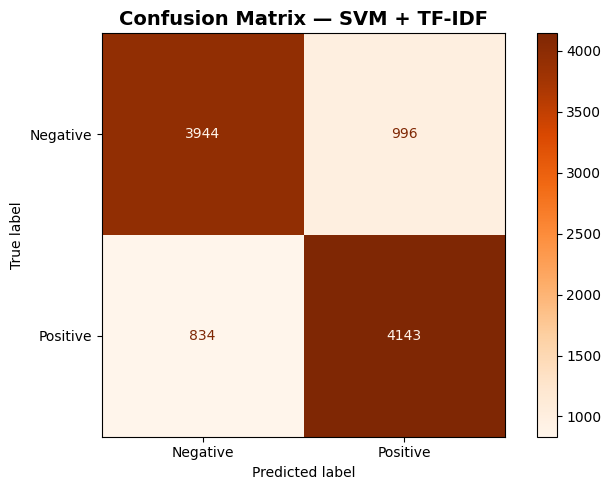

In [11]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Oranges', ax=ax, values_format='d')
ax.set_title('Confusion Matrix — SVM + TF-IDF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Feature Importance Analysis

In [12]:
# Top features from SVM coefficients
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = svm_model.coef_[0]

top_pos = np.argsort(coefficients)[-15:]
top_neg = np.argsort(coefficients)[:15]

print('Top 15 POSITIVE sentiment features:')
for idx in reversed(top_pos):
    print(f'  {feature_names[idx]:20s} ({coefficients[idx]:.4f})')

print('\nTop 15 NEGATIVE sentiment features:')
for idx in top_neg:
    print(f'  {feature_names[idx]:20s} ({coefficients[idx]:.4f})')

Top 15 POSITIVE sentiment features:
  excellent            (2.0283)
  great                (1.8899)
  perfect              (1.7957)
  wonderful            (1.4696)
  best                 (1.4296)
  definitely           (1.1335)
  love                 (1.0968)
  well                 (1.0518)
  fun                  (1.0060)
  especially           (0.9772)
  dvd                  (0.9501)
  beautiful            (0.8708)
  always               (0.8682)
  classic              (0.8668)
  also                 (0.8506)

Top 15 NEGATIVE sentiment features:
  worst                (-3.6490)
  awful                (-2.9843)
  boring               (-2.2632)
  bad                  (-2.2554)
  terrible             (-2.2261)
  poor                 (-2.0264)
  stupid               (-1.6057)
  nothing              (-1.5371)
  instead              (-1.2300)
  minute               (-1.2225)
  script               (-1.1514)
  money                (-1.0497)
  attempt              (-1.0119)
  even            

---
## 9. Analysis and Discussion

### Observations
- **TF-IDF** provides superior feature weighting compared to raw BoW by penalizing common terms.
- **Bigrams** (ngram_range=(1,2)) capture short phrases with sentiment meaning (e.g., "not good").
- **Linear SVM** is well-suited for high-dimensional sparse text data.

### Advantages
- TF-IDF weighting reduces noise from uninformative terms.
- SVM's margin maximization provides robust generalization.
- Efficient training and prediction on sparse matrices.

### Limitations
- Still a bag-of-words approach — no semantic understanding.
- 300 features may exclude important lower-frequency discriminative terms.
- Cannot capture long-range dependencies or complex linguistic patterns.